Mean mu: 55.189296875
-----
Pixel row 0.0 col 0.0, mu: 48.14, T_up_tuner: 1, TDAC_tuner: 7, Mu distance: 7.05
-----
Pixel row 0.0 col 1.0, mu: 65.21, T_up_tuner: 0, TDAC_tuner: 11, Mu distance: -10.02
-----
Pixel row 0.0 col 2.0, mu: 52.05, T_up_tuner: 1, TDAC_tuner: 3, Mu distance: 3.14
-----
Pixel row 0.0 col 3.0, mu: 62.86, T_up_tuner: 0, TDAC_tuner: 8, Mu distance: -7.67
-----
Pixel row 0.0 col 4.0, mu: 48.69, T_up_tuner: 1, TDAC_tuner: 7, Mu distance: 6.5
-----
Pixel row 0.0 col 5.0, mu: 48.9, T_up_tuner: 1, TDAC_tuner: 6, Mu distance: 6.29
-----
Pixel row 0.0 col 6.0, mu: 41.97, T_up_tuner: 1, TDAC_tuner: 14, Mu distance: 13.22
-----
Pixel row 0.0 col 7.0, mu: 65.93, T_up_tuner: 0, TDAC_tuner: 11, Mu distance: -10.74
-----
Pixel row 1.0 col 0.0, mu: 62.3, T_up_tuner: 0, TDAC_tuner: 7, Mu distance: -7.11
-----
Pixel row 1.0 col 1.0, mu: 51.51, T_up_tuner: 1, TDAC_tuner: 4, Mu distance: 3.68
-----
Pixel row 1.0 col 2.0, mu: 64.4, T_up_tuner: 0, TDAC_tuner: 10, Mu distance: -9.21
--

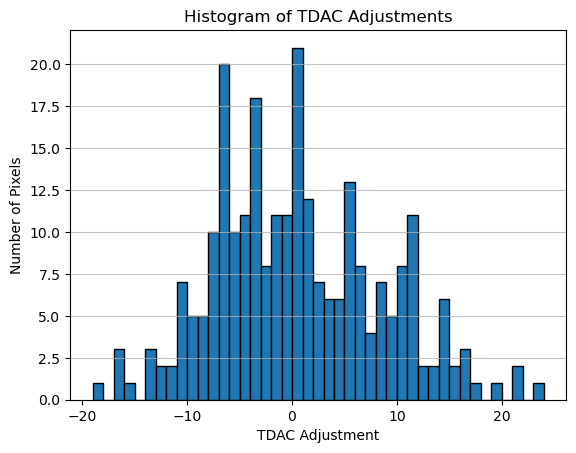

In [2]:
import pandas as pd


# apri il file scurve_fit_results.csv e mostra le prime righe
verify_df = pd.read_csv("scurve_tdac0_fit_results.csv")


# considera il fit lineare calcolato da Fit results: mu = 0.90 * TDAC + 53.85
def tdac_to_mu(tdac_code):
    return 0.90 * tdac_code + 53.85

def mu_to_tdac(mu):
    return (mu - 53.85) / 0.90


def tune(target_mu, pixel_mu):
    tup=0
    mu_distance = round(target_mu - pixel_mu,2)
    tdac_adjustment = int(mu_distance / 0.90)

    if tdac_adjustment > 0:
        tup = 1


    #print(f"Target mu: {target_mu}, Pixel mu: {pixel_mu}")
    #print(f"Mu distance: {mu_distance}, TDAC adjustment: {tdac_adjustment}")

    return tup, abs(tdac_adjustment), mu_distance


# da verify_df calcola la media delle mu
mean_mu = verify_df['mu'].mean()
print(f"Mean mu: {mean_mu}")

# per ogni pixel del file calcola il tdac adjustment per portare la mu alla media
tdac_codes_tuned = []
for index, row in verify_df.iterrows():
    pixel_mu = row['mu']
    t_up_tuner, tdac_tuner, mu_distance = tune(mean_mu, pixel_mu)
    tdac_codes_tuned.append((int(row["row"]), int(row["col"]), t_up_tuner, tdac_tuner))
    print("-----")
    print(f"Pixel row {row['row']} col {row['col']}, mu: {pixel_mu}, T_up_tuner: {t_up_tuner}, TDAC_tuner: {tdac_tuner}, Mu distance: {mu_distance}")

# plot istogramma degli aggiustamenti TDAC e tup, considerando tdac_negativo se associato a tup=1
import matplotlib.pyplot as plt
# tdac_codes_tuned contiene tuple (row, col, tup, tdac) — decomponiamo correttamente
tdac_adjustments = [tdac if tup == 0 else -tdac for (_, _, tup, tdac) in tdac_codes_tuned]
plt.hist(tdac_adjustments, bins=range(min(tdac_adjustments), max(tdac_adjustments) + 1, 1), edgecolor='black')
plt.title("Histogram of TDAC Adjustments")
plt.xlabel("TDAC Adjustment")
plt.ylabel("Number of Pixels")
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:

# Range correttivo dei mu medi: 56.38 mV
# Ogni step del TDAC corrisponde a un cambiamento di mu di circa: 0.89 mV
# Quindi il numero di step TDAC necessari per coprire l'intero intervallo è:
mu_range = verify_df['mu'].max() - verify_df['mu'].min()
tdac_step_size = 0.90  # mV per step TDAC
num_tdac_steps = mu_range / tdac_step_size
print(f"Mu range: {mu_range} mV")
print(f"Number of TDAC steps needed to cover the mu range: {num_tdac_steps}")
"""
# da verify_df calcola la media delle mu
mean_mu = verify_df['mu'].mean()
print(f"Mean mu: {mean_mu}")

#seleziona un pixel specifico, ad esempio row=10, col=6
specific_pixel = verify_df[(verify_df['row'] == 10) & (verify_df['col'] == 6)].iloc[0]
print(specific_pixel['mu'])




# calcolo l'errore che c'è tra il mu misurato e quello target
error_mu = abs(mean_mu - specific_pixel['mu'])
print(f"Error mu for pixel (10,6): {error_mu}")

# se mu del pixel è più alto del target, allora devo diminuire il mu, quindi tup=1, altrimenti tup=0
if specific_pixel['mu'] > mean_mu:
    tup = 1
else:
    tup = 0

# considerando che la correzione di ciascun step TDAC è di 0.90 mV, calcolo di quanti step TDAC ho bisogno per correggere l'errore
tdac_steps_needed = int(error_mu / 0.90)
print(f"TDAC steps needed for pixel (10,6): {tdac_steps_needed} with T_up_tuner: {tup}")
"""

def compute_tdac_corrections(df, target_mu=None, tdac_step_size=tdac_step_size):
    """
    Per ogni pixel calcola:
      - error_mu: valore assoluto della differenza tra target_mu e mu del pixel
      - tup: 1 se il mu del pixel > target_mu (serve a diminuire il mu), altrimenti 0
      - tdac_steps: numero intero di step TDAC necessari (troncamento come nel codice precedente)
    Restituisce una lista di tuple: (row, col, tup, tdac_steps)
    """
    if target_mu is None:
        target_mu = df['mu'].mean()
    results = []
    for _, pix in df.iterrows():
        mu = pix['mu']
        error_mu = abs(target_mu - mu)
        tup = 0 if mu > target_mu else 1
        tdac_steps = int(error_mu / tdac_step_size)
        results.append((int(pix['row']), int(pix['col']), tup, tdac_steps)) # error_mu, mu))
    return results

# uso: calcola le correzioni usando la mean_mu già presente
tdac_corrections = compute_tdac_corrections(verify_df, target_mu=mean_mu)
print(tdac_corrections)



Mu range: 39.34 mV
Number of TDAC steps needed to cover the mu range: 43.711111111111116
[(0, 0, 0, 7), (0, 1, 1, 11), (0, 2, 0, 3), (0, 3, 1, 8), (0, 4, 0, 7), (0, 5, 0, 6), (0, 6, 0, 14), (0, 7, 1, 11), (1, 0, 1, 7), (1, 1, 0, 4), (1, 2, 1, 10), (1, 3, 0, 7), (1, 4, 0, 8), (1, 5, 1, 10), (1, 6, 0, 7), (1, 7, 0, 6), (2, 0, 0, 8), (2, 1, 1, 1), (2, 2, 1, 7), (2, 3, 1, 11), (2, 4, 1, 11), (2, 5, 1, 10), (2, 6, 0, 5), (2, 7, 1, 14), (3, 0, 1, 2), (3, 1, 0, 1), (3, 2, 1, 0), (3, 3, 1, 0), (3, 4, 0, 10), (3, 5, 1, 12), (3, 6, 1, 12), (3, 7, 1, 9), (4, 0, 1, 0), (4, 1, 0, 11), (4, 2, 0, 6), (4, 3, 0, 1), (4, 4, 0, 14), (4, 5, 0, 4), (4, 6, 0, 5), (4, 7, 1, 6), (5, 0, 0, 4), (5, 1, 1, 16), (5, 2, 1, 4), (5, 3, 1, 13), (5, 4, 0, 5), (5, 5, 1, 6), (5, 6, 1, 2), (5, 7, 1, 11), (6, 0, 0, 3), (6, 1, 1, 1), (6, 2, 0, 4), (6, 3, 0, 6), (6, 4, 0, 5), (6, 5, 1, 6), (6, 6, 0, 7), (6, 7, 0, 3), (7, 0, 0, 13), (7, 1, 0, 7), (7, 2, 1, 3), (7, 3, 0, 1), (7, 4, 0, 7), (7, 5, 1, 7), (7, 6, 0, 2), (7, 7, 1, 

In [27]:
# crea un file tsv con le colonne: pixel_index, t_up_tuner, tdac_tuner
with open("tdac_tuning_results.tsv", "w") as f:
    f.write("row\tcol\tt_up_tuner\ttdac_tuner\n")
    for index, (row, col, t_up_tuner, tdac_tuner) in enumerate(tdac_corrections):
        f.write(f"{row}\t{col}\t{t_up_tuner}\t{tdac_tuner}\n")